## Run a pipeline using a dask gateway cluster

This process will run the entire pipeline described in a configuration file using a dask gateway cluster (LocalCluster

## Import dependencies

In [1]:
%load_ext autoreload
%autoreload 2
from paidiverpy.pipeline import Pipeline

## Instantiate the Pipeline Class

In [2]:
pipeline = Pipeline(config_file_path="../config_files/config_benthic_client.yml", verbose=2)

☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:35 | No dataset UUID found in the dataset metadata. A new UUID has been generated: a2a2733e-afde-48db-ade1-540e1e59cb4d


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:37 | Created LocalCluster with Client: http://127.0.0.1:8787/status


As you can see, when you instantiate the Pipeline class with this configuration file, a LocalCluster is created and you can access the dashboard in the link above.

This occours because we have the following parameters in the configuration file, as you can see below:

```yaml
n_jobs: 2,
client:
  cluster_type": "local"
  params":
    n_workers: 4
    threads_per_worker: 4
    memory_limit": "8GB"
```


In [3]:
pipeline.config

{
    "general": {
        "name": "raw",
        "step_name": "open",
        "sample_data": "benthic_csv",
        "input_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/images",
        "output_path": "output",
        "metadata_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv",
        "metadata_type": "CSV_FILE",
        "image_open_args": "PNG",
        "append_data_to_metadata": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv",
        "n_jobs": 2,
        "client": {
            "cluster_type": "local",
            "params": {
                "n_workers": 4,
                "threads_per_worker": 4,
                "memory_limit": "8GB"
            }
        },
        "track_changes": false,
        "sampling": [
            {
                "name": "sampling",
                "step_name": "sampling",
                "test": false,
                "params": {
                    "value": 20,
                    "raise_error": false
                },
                "mode": "fixed"
            }
        ]
    },
    "steps": [
        {
            "name": "colour_alteration",
            "step_name": "colour",
            "test": false,
            "params": {
                "method": "white_balance",
                "raise_error": false
            },
            "mode": "colour_alteration"
        },
        {
            "name": "gaussian_blur",
            "step_name": "colour",
            "test": false,
            "params": {
                "sigma": 1.0,
                "raise_error": false
            },
            "mode": "gaussian_blur"
        },
        {
            "name": "sharpen",
            "step_name": "colour",
            "test": false,
            "params": {
                "alpha": 1.5,
                "beta": -0.5,
                "raise_error": false
            },
            "mode": "sharpen"
        },
        {
            "name": "contrast",
            "step_name": "colour",
            "test": false,
            "params": {
                "method": "clahe",
                "clip_limit": 0.01,
                "gamma_value": 0.5,
                "raise_error": false
            },
            "mode": "contrast"
        }
    ]
}

In [4]:
# See the pipeline steps. Click in a step to see more information about it
pipeline

## Run the pipeline

You can follow the workers on the dashboard provided

In [5]:
# Run the pipeline
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:37 | Processing images using Dask client at: http://127.0.0.1:8787/status


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:37 | Running step 0: raw - OpenLayer


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:40 | Step 0 completed


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:40 | Running step 1: colour_alteration - ColourLayer


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:42 | Step 1 completed


...

☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:43 | Step 2 completed


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:43 | Running step 3: sharpen - ColourLayer


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:44 | Step 3 completed


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:45 | Running step 4: contrast - ColourLayer


☁ paidiverpy ☁  |       INFO | 2026-05-09 16:57:46 | Step 4 completed


In [6]:
pipeline.client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 8,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33015,Workers: 2
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 14.90 GiB
Comm: tcp://127.0.0.1:44671,Total threads: 4
Dashboard: http://127.0.0.1:33523/status,Memory: 7.45 GiB
Nanny: tcp://127.0.0.1:34823,


## See the images

Because you include in the configuration file the argument "track_changes: False", only the output of the last layer will be saved.
This is a strategy to save memory when you are processing a big dataset


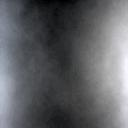
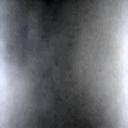
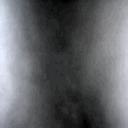
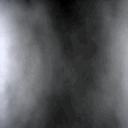
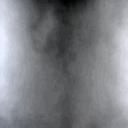
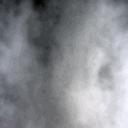
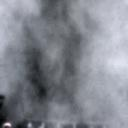
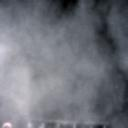
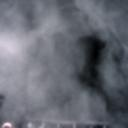
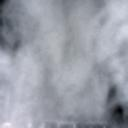
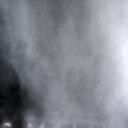
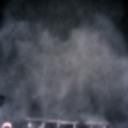

In [7]:
pipeline.images